# Notebook containing the boosting model

Notebook to run the model :
- Data pre-processing
- Model training
- Model evaluation
- Shap values computation

Target : has to be set in the vote variable (participation, political leaning, etc)
Elections considered : allow to select one / multiple election

## Imports

In [7]:
import os

# os.chdir("/home/damien/work/elections/election_modeling_uhcp")
# cwd = os.getcwd()
# if not cwd.endswith("ml"):
#     os.chdir("ml")

In [11]:
import pandas as pd
import polars as pl  # Add to requirments
import numpy as np

from sklearn.model_selection import train_test_split
import shap
from xgboost import XGBRegressor

import matplotlib.pyplot as plt

import joblib
from datetime import datetime
import s3fs

In [12]:
os.environ["AWS_ACCESS_KEY_ID"] = "27KB5QH8DUUIKWUA6RUQ"
os.environ["AWS_SECRET_ACCESS_KEY"] = "muqEL6++FbJfbh6fzHF8gqEPjjtCnbI5qVIp+78Z"
os.environ["AWS_SESSION_TOKEN"] = (
    "eyJhbGciOiJIUzUxMiIsInR5cCI6IkpXVCJ9.eyJhY2Nlc3NLZXkiOiIyN0tCNVFIOERVVUlLV1VBNlJVUSIsImFsbG93ZWQtb3JpZ2lucyI6WyIqIl0sImF1ZCI6WyJtaW5pby1kYXRhbm9kZSIsIm9ueXhpYSIsImFjY291bnQiXSwiYXV0aF90aW1lIjoxNzY1Mzc5MDAxLCJhenAiOiJvbnl4aWEiLCJlbWFpbCI6ImFydGh1ci5tYW5jZWF1QHN0dWRlbnQtY3MuZnIiLCJlbWFpbF92ZXJpZmllZCI6dHJ1ZSwiZXhwIjoxNzY2OTIwNzMyLCJmYW1pbHlfbmFtZSI6Ik1hbmNlYXUiLCJnaXZlbl9uYW1lIjoiQXJ0aHVyIiwiZ3JvdXBzIjpbIlVTRVJfT05ZWElBIl0sImlhdCI6MTc2NjMxNTkzMiwiaXNzIjoiaHR0cHM6Ly9hdXRoLmxhYi5zc3BjbG91ZC5mci9hdXRoL3JlYWxtcy9zc3BjbG91ZCIsImp0aSI6Im9ucnRydDpiNzM3ODg1Yi1kYjAyLTYxYmQtMDllNS00MmYzMzVjN2IyODMiLCJsb2NhbGUiOiJlbiIsIm5hbWUiOiJBcnRodXIgTWFuY2VhdSIsInBvbGljeSI6InN0c29ubHkiLCJwcmVmZXJyZWRfdXNlcm5hbWUiOiJhcnRodXJtYW5jZWF1IiwicmVhbG1fYWNjZXNzIjp7InJvbGVzIjpbIm9mZmxpbmVfYWNjZXNzIiwidW1hX2F1dGhvcml6YXRpb24iLCJkZWZhdWx0LXJvbGVzLXNzcGNsb3VkIl19LCJyZXNvdXJjZV9hY2Nlc3MiOnsiYWNjb3VudCI6eyJyb2xlcyI6WyJtYW5hZ2UtYWNjb3VudCIsIm1hbmFnZS1hY2NvdW50LWxpbmtzIiwidmlldy1wcm9maWxlIl19fSwicm9sZXMiOlsib2ZmbGluZV9hY2Nlc3MiLCJ1bWFfYXV0aG9yaXphdGlvbiIsImRlZmF1bHQtcm9sZXMtc3NwY2xvdWQiXSwic2NvcGUiOiJvcGVuaWQgcHJvZmlsZSBncm91cHMgZW1haWwiLCJzaWQiOiJiMmMzNGJmNS02MTcwLTQyOGYtYmNlMC1lNGM4OGFhN2ViNmMiLCJzdWIiOiJiYzc3Yjk3YS1lN2VkLTQ4ZWMtYmQ4Zi1lNzBjYjZhMTYyZGIiLCJ0eXAiOiJCZWFyZXIifQ.II7YB21CRXq3HCSNT9-DYw-UDoUn8aT3yIGy41I6Ktk1WH4v0xv-nGX2JIHnzjPUx83EI7orRsuIXUNH9D_ORw"
)
os.environ["AWS_DEFAULT_REGION"] = "us-east-1"
fs = s3fs.S3FileSystem(
    client_kwargs={"endpoint_url": "https://" + "minio.lab.sspcloud.fr"},
    key=os.environ["AWS_ACCESS_KEY_ID"],
    secret=os.environ["AWS_SECRET_ACCESS_KEY"],
    token=os.environ["AWS_SESSION_TOKEN"],
)

In [ ]:
data = pd.read_parquet(
    "s3://arthurmanceau/election_modeling_uhcp/data/derived/processed/data_ppar_pvoteG_pvoteC_pvoteD_pvoteCG_pvoteCD_1970_presidentiel_legislative_20251216_165954.parquet",
    filesystem=fs,
)

In [15]:
data.drop(columns=["dep"], inplace=True)

In [16]:
df = pl.from_pandas(data)

df = df.select(pl.exclude(r"^.*/pop$"))  # remove raw population
df_pop = df.select(pl.col(r"^.*/pop.*(rank|change)$"))  # keep population ranks

df = df.select(
    pl.exclude(r"^.*/pop.*$")
)  # remove all other population related features
df = pl.concat([df, df_pop], how="horizontal")  # add back population ranks

In [17]:
years_type_0 = (
    df.filter(pl.col("type") == 0).select("annee").unique().to_series().to_list()
)
years_type_1 = (
    df.filter(pl.col("type") == 1).select("annee").unique().to_series().to_list()
)
years_type_0.sort()
years_type_1.sort()
years_type_0 = np.array(years_type_0)
years_type_1 = np.array(years_type_1)

In [ ]:
import os

from sklearn.model_selection import KFold
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)


def perform_nested_cv(
    X,
    y,
    weights,
    n_splits_outer=3,
    n_splits_inner=3,
    n_trials=3,
    use_gpu=True,
    ml_model="xgboost",
):
    """
    Perform nested cross-validation with hyperparameter tuning using Optuna.

    Parameters:
        X (array-like): Feature matrix.
        y (array-like): Target vector.

        Returns:
        best_params_list_outer (list): List of best hyperparameters from outer folds.
        best_test_scores_list_outer (list): List of test scores from outer folds.
    """

    # Define the number of folds for cross-validation

    if np.any(np.isnan(y)):
        print(np.where(np.isnan(y)))
        raise ValueError(
            "Target variable y contains NaN values. Please handle them before proceeding."
        )

    if use_gpu:
        import cupy as cp

        X = cp.array(X)
        y = cp.array(y)
        weights = cp.array(weights)

    else:
        X = np.array(X)
        y = np.array(y)
        weights = np.array(weights)

    kf_outer = KFold(n_splits=n_splits_outer, shuffle=True, random_state=42)
    kf_inner = KFold(n_splits=n_splits_inner, shuffle=True, random_state=24)

    best_params_list_outer = []
    best_test_scores_list_outer = []

    fold_outer = 0
    for train_index_outer, test_index_outer in kf_outer.split(X):
        fold_outer += 1
        X_train_outer, X_test = X[train_index_outer], X[test_index_outer]
        y_train_outer, y_test = y[train_index_outer], y[test_index_outer]

        if np.any(np.isnan(y_train_outer)):
            print(np.where(np.isnan(y_train_outer)))
            raise ValueError(
                "Target variable y_train_outer contains NaN values. Please handle them before proceeding."
            )

        # print(X_train_outer.sum(), X_test.sum())
        # print(y_train_outer.sum(), y_test.sum())

        if use_gpu:
            y_test = y_test.get()

        best_params_list = []
        fold_inner = 0
        for train_index, val_index in kf_inner.split(X_train_outer):
            fold_inner += 1
            #  print(f"Fold outer {fold_outer} fold inner {fold_inner}            \t")

            X_train, X_val = X_train_outer[train_index], X_train_outer[val_index]
            y_train, y_val = y_train_outer[train_index], y_train_outer[val_index]
            weights_train = weights[train_index]

            # print(X_train.sum(), X_val.sum())
            # print(y_train.sum(), y_val.sum())

            if use_gpu:
                y_val = y_val.get()

            def objective(trial):
                param = {
                    "max_depth": trial.suggest_int("max_depth", 3, 10),
                    "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
                    "n_estimators": trial.suggest_int("n_estimators", 100, 150),
                    #                   'subsample': trial.suggest_float('subsample', 0.5, 0.9),
                    #                   'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
                    #                   'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
                    "gamma": trial.suggest_float("gamma", 0, 0.5),
                }

                if use_gpu:
                    model_g = XGBRegressor(**param, device="cuda")
                else:
                    model_g = XGBRegressor(**param)

                model_g.fit(X_train, y_train, sample_weight=weights_train)

                # Evaluate model on validation set
                if use_gpu:
                    y_pred = cp.array(model_g.predict(X_val)).get()
                else:
                    y_pred = model_g.predict(X_val)

                if use_gpu:
                    y_pred = y_pred.get()

                val_score = np.sqrt(((y_pred.flatten() - y_val.flatten()) ** 2)).mean()

                del model_g

                return val_score

            # Create and run the optimization process with 100 trials
            study = optuna.create_study(
                study_name="example_xgboost_study",
                direction="minimize",
                sampler=optuna.samplers.TPESampler(),
            )
            study.optimize(
                objective, n_trials=n_trials, show_progress_bar=False, n_jobs=2
            )

            # Retrieve the best parameter values
            best_params = study.best_params
            # print(f"\n best parameters inner: {best_params}")
            best_params_list.append(best_params)

        # Evaluate the best models from inner folds on the outer test set
        # print(" evaluating best models from inner folds on the full inner set")
        test_scores = []
        for i, param in enumerate(best_params_list):
            if use_gpu:
                model_g = XGBRegressor(**param, device="cuda")
            else:
                model_g = XGBRegressor(**param)
            model_g.fit(
                X_train_outer, y_train_outer, sample_weight=weights[train_index_outer]
            )
            y_pred = model_g.predict(X_test)

            #  if use_gpu:
            #            y_pred = y_pred.get()
            val_score = np.sqrt(((y_pred.flatten() - y_test.flatten()) ** 2)).mean()
            test_scores.append(val_score)
        # and take the best one
        idx_best = np.argmin(test_scores)
        #    print(f" best model is model {idx_best} with params {best_params_list[idx_best]} and test score {test_scores[idx_best]}")
        best_params_list_outer.append(best_params_list[idx_best])
        best_test_scores_list_outer.append(test_scores[idx_best])
    # Finally, train the best models on the entire dataset
    # print("Training best models on the entire dataset")
    best_models = []
    for params in best_params_list_outer:
        if use_gpu:
            model_g = XGBRegressor(**params, device="cuda")
        else:
            model_g = XGBRegressor(**params)
        model_g.fit(X, y, sample_weight=weights)
        best_models.append(model_g)

    return best_models, best_params_list_outer, best_test_scores_list_outer


def Xy_from_data(df, target, columns_to_exclude=[], nan_rm=True):
    X = df.select(pl.exclude(target))
    X = X.drop(columns_to_exclude, strict=False)

    X_cls = X.columns
    X = np.float32(X.to_numpy())
    y = df.select(target).to_numpy()
    y = np.float32(y)
    if nan_rm:
        mask = ~np.isnan(y).flatten()
        X = X[mask]
        y = y[mask]

    codecommune = df.select("codecommune").to_numpy().flatten()[mask]

    return X, y, X_cls, codecommune


def feature_importance_mean(models, feature_names, num_top, plot=False):
    """
    Calculate and plot feature importance from a list of trained models.

    Parameters:
        models (list): List of trained models.
        feature_names (list): List of feature names.

    Returns:
        None
    """
    importances = np.zeros(len(feature_names))
    for model in models:
        importances += model.feature_importances_

    importances /= len(models)

    # Create a DataFrame for better visualization
    importance_df = pd.DataFrame(
        {"Feature": feature_names, "Importance": importances}
    ).sort_values(by="Importance", ascending=False)

    # Plotting
    if plot:
        importance_df.iloc[:num_top].plot(
            kind="bar", x="Feature", y="Importance", legend=False
        )
    return importance_df


def train_explain(
    df,
    n_splits_outer,
    n_splits_inner,
    n_trials,
    use_gpu,
    year_start,
    year_stop,
    what,  # 0: presidentiel, 1: legislative
    target,
    remove_previous,
    use_hand_picked_features,
    #                    index = 'codecommune',
    targets,
    features_to_exclude=["annee", "type", "long", "lat"],
    num_top=30,
    with_rank=False,
    with_pctchange=False,
    with_delta=False,
    dirResults="results",
    weighting=None,  # None, or "proportional", or "sqrt"
):
    features_to_exclude_str = ":".join(
        [f.replace("/", "-") for f in features_to_exclude]
    )

    subdir = f"{year_start}-{year_stop}_{target}_{what}_handpicked{use_hand_picked_features}_noprev{remove_previous}_featex:{features_to_exclude_str}_rank:{with_rank}_pctchange:{with_pctchange}_delta:{with_delta}_weighting:{weighting}_num_top:{num_top}_nsplitouter:{n_splits_outer}_nsplitinner:{n_splits_inner}_ntrials:{n_trials}"
    dirRes_full = dirResults + "/" + subdir

    print(f"Saving results to {dirRes_full}")

    if not os.path.exists(dirResults + "/" + subdir):
        os.makedirs(dirResults + "/" + subdir)

    if os.path.isfile(dirRes_full + "/X_top.jbl"):
        print(f"Results already exist in {dirRes_full}, skipping training.")
        return

    if target not in df.columns:
        if "diff" in target:
            # compute diffs
            for t in targets[: len(targets) // 2]:
                col_previous = t.replace(
                    "pvote", "pvoteprevious", 1
                )  # first occurence only
                new_col = t.replace("pvote", "pvote_diff_pv", 1)
                print(f"Creating column {new_col} = {t} - {col_previous}")
                df = df.with_columns((pl.col(t) - pl.col(col_previous)).alias(new_col))
        else:
            raise ValueError(f"Target column {target} not found in dataframe.")

    if remove_previous:
        df = df.select(pl.exclude(r"^.*previous.*$"))

    if use_hand_picked_features:
        from config.features_hand_sel import features_hand_sel

        # print(f"{len(features_hand_sel)} hand-picked features loaded")
        if not remove_previous:
            features_hand_sel = features_hand_sel + [
                target.replace("pvote", "pvoteprevious", 1)
            ]
        df_sub = df.select(["annee", "type", "codecommune", target] + features_hand_sel)

    else:
        # df_notp = df.select(pl.exclude(r"^.*/[^p].*$")) # only keep proportion columns (otherwise, everthing is proportional to size)
        # df_pct = df.select(r"^.*change$") # only keep percentage columns (otherwise, everthing is proportional to size)
        # df_pct = df_pct.select(pl.exclude(df_notp.columns))
        # df_sub = pl.concat([df_notp, df_pct], how = "horizontal")
        # df_sub = df.select(pl.exclude(r"^.*rank$"))
        # df_sub.shape
        df_sub = df
        if not with_rank:
            df_sub = df_sub.select(pl.exclude(r"^.*rank$"))
        if not with_pctchange:
            df_sub = df_sub.select(pl.exclude(r"^.*pctchange$"))
        if not with_delta:
            df_sub = df_sub.select(pl.exclude(r"^.*delta$"))

        df_sub = df_sub.select(pl.exclude(r"^.*\/per.*$"))

    if target not in df_sub.columns:
        df_sub = pl.concat([df_sub, df.select(target)], how="horizontal")
    if "annee" not in df_sub.columns:
        df_sub = pl.concat([df_sub, df.select("annee")], how="horizontal")
    if "type" not in df_sub.columns:
        df_sub = pl.concat([df_sub, df.select("type")], how="horizontal")

    if "codecommune" not in df_sub.columns:
        df_sub = pl.concat([df_sub, df.select("codecommune")], how="horizontal")
    #    df_sub = pl.concat([df_sub,df.select([target,"annee","type"])],how="horizontal",)

    df_sel = df_sub.filter(
        (pl.col("annee") >= year_start)
        & (pl.col("annee") <= year_stop)
        & (pl.col("type") == what)
    )
    df_sel = df_sel.select(pl.exclude(["type"]))

    df_sel = df_sel.fill_nan(0)

    X, y, features, codecommune = Xy_from_data(
        df_sel,
        target,
        columns_to_exclude=features_to_exclude + targets + ["codecommune"],
    )

    if weighting is None:
        weights = np.ones_like(y)
    else:
        inscrits = df_sel.select("inscrits").to_numpy().flatten()
        if weighting == "proportional":
            weights = inscrits
        elif weighting == "sqrt":
            weights = np.sqrt(inscrits)
        elif weighting == "inverse":
            weights = 1.0 / (inscrits + 1e-6)
        elif weighting == "inverse_y":
            weights = 1.0 / (y.flatten() + 1e-6)
        else:
            raise ValueError(
                "weighting_inscrits must be None, 'proportional', or 'sqrt'."
            )
        weights = weights / np.mean(weights)

    file_models = f"{dirRes_full}/best_models.jbl"
    if not os.path.exists(file_models):
        best_models, best_params, best_scores = perform_nested_cv(
            X,
            y,
            n_splits_outer=n_splits_outer,
            n_splits_inner=n_splits_inner,
            n_trials=n_trials,
            use_gpu=use_gpu,
            weights=weights,
        )
        joblib.dump(best_models, file_models)
    else:
        best_models = joblib.load(file_models)

    features_df = feature_importance_mean(best_models, features, num_top, plot=False)
    joblib.dump(features_df, f"{dirRes_full}/feature_importances.jbl")
    features_imp = features_df["Importance"].values

    sel_features = features_imp > 2 * (np.median(features_imp))

    if sel_features.sum() == 0:
        sel_features = features_imp == np.max(features_imp)

    features_top = features_df["Feature"].values[sel_features][:num_top]
    features_top = list(features_top)

    X_top, y_top, features_top, codecommunes_top = Xy_from_data(
        df_sel.select([target, "codecommune"] + features_top),
        target,
        columns_to_exclude=features_to_exclude + ["codecommune"],
    )

    file_X = f"{dirRes_full}/X_top.jbl"
    file_y = f"{dirRes_full}/y_top.jbl"
    file_features_top = f"{dirRes_full}/features_top.jbl"
    file_codecommunes_top = f"{dirRes_full}/codecommunes_top.jbl"

    joblib.dump(X_top, file_X)
    joblib.dump(y_top, file_y)
    joblib.dump(features_top, file_features_top)
    joblib.dump(codecommunes_top, file_codecommunes_top)

    if np.any(np.isnan(y_top)):
        print(np.where(np.isnan(y_top)))
        raise ValueError(
            "Target variable y_top contains NaN values. Please handle them before proceeding."
        )

    file_models_top = f"{dirRes_full}/best_models_top.jbl"
    if not os.path.exists(file_models_top):
        best_models_top, best_params_top, best_scores_top = perform_nested_cv(
            X_top,
            y_top,
            n_splits_outer=n_splits_outer,
            n_splits_inner=n_splits_inner,
            n_trials=n_trials,
            use_gpu=use_gpu,
            weights=weights,
        )
        joblib.dump(best_models_top, file_models_top)
    else:
        best_models_top = joblib.load(file_models_top)

    if use_gpu:
        import cupy as cp

        X_top = cp.array(X_top)

    y_preds = []
    for model in best_models_top:
        y_pred = model.predict(X_top)
        y_preds.append(y_pred)

    file_ypreds = f"{dirRes_full}/y_preds_top.jbl"
    joblib.dump(y_preds, file_ypreds)

    if use_gpu:
        X_top = X_top.get()

    importance_top_df = feature_importance_mean(
        best_models_top, features_top, num_top=num_top
    )

    # Plot top  features
    top_n = num_top
    top_features = importance_top_df.head(top_n)

    plt.figure(figsize=(10, 5))
    plt.bar(top_features["Feature"], top_features["Importance"])
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Feature")
    plt.ylabel("Importance")
    plt.title(f"Top {top_n} Feature Importances")
    plt.tight_layout()
    file_fig_topfeatures = f"{dirRes_full}/feature_importance_top_.pdf"
    plt.savefig(file_fig_topfeatures)
    # plt.yscale("log")
    plt.show()

    file_shap = f"{dirRes_full}/shap_explainers_top.jbl"
    if not os.path.exists(file_shap):
        explainers = []

        shap_values_list = []
        for model_g in best_models_top:
            explainer = shap.explainers.GPUTree(
                model_g, pd.DataFrame(X_top, columns=features_top)
            )
            # explainer = shap.explainers.Tree(model_g, X_top)
            # explainers.append(explainer)
            shap_values = explainer(X_top, check_additivity=False)
            #    booster = model_g.get_booster()
            #    dtop = DMatrix(X_top)
            #    shap_values = booster.predict(dtop, pred_contribs=True)
            shap_values_list.append(shap_values)

        # Average SHAP values across all models

        # Convert each SHAP values object to its .values array
        shap_arrays = [sv.values for sv in shap_values_list]
        avg_shap_values = np.mean(shap_arrays, axis=0)

        # If you want a SHAP values object with averaged values for further SHAP plotting:
        shap_values = shap.Explanation(
            values=avg_shap_values,
            base_values=shap_values_list[0].base_values,
            data=shap_values_list[0].data,
            feature_names=shap_values_list[0].feature_names,
        )

        joblib.dump(shap_values, file_shap)
    else:
        shap_values = joblib.load(file_shap)

    # Summary plot for all features
    file_fig_shap = f"{dirRes_full}/shap_violin_top.pdf"
    shap.summary_plot(shap_values, X_top, feature_names=features_top, show=False)
    plt.savefig(file_fig_shap)
    plt.close()

    for idx in range(len(features_top)):
        feature_clean = features_top[idx].replace("/", ":")
        file_fig_shap_dep = f"{dirRes_full}/shap_dependence_{feature_clean}.pdf"
        shap.dependence_plot(
            idx, shap_values.values, X_top, show=False, feature_names=features_top
        )
        plt.title(target)
        plt.savefig(file_fig_shap_dep)
        plt.close()

    return best_models, best_models_top, shap_values, features_top

************************
Type 0, processing years 2002 to 2002
***********  pvoteppar  ***********
Saving results to results/2002-2002_pvoteppar_0_handpickedFalse_noprevFalse_featex:_rank:False_pctchange:False_delta:False_weighting:proportional_num_top:30_nsplitouter:10_nsplitinner:10_ntrials:10


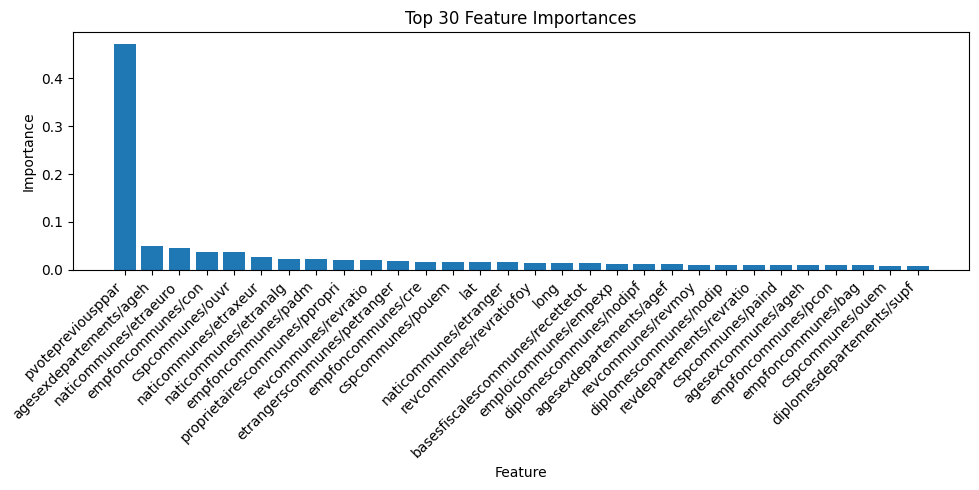

cuda extension was not built during install!


ImportError: cannot import name '_cext_gpu' from partially initialized module 'shap' (most likely due to a circular import) (/home/onyxia/work/.venv/lib/python3.13/site-packages/shap/__init__.py)

In [19]:
n_splits_inner = 10
n_splits_outer = 10
n_trials = 10
use_gpu = False
targets = [
    "pvoteppar",
    "pvotepvoteG",
    "pvotepvoteC",
    "pvotepvoteD",
    "pvotepvoteCG",
    "pvotepvoteCD",
] + [
    "pvote_diff_pvppar",
    "pvote_diff_pvpvoteG",
    "pvote_diff_pvvoteC",
    "pvote_diff_pvvoteD",
    "pvote_diff_pvvoteCG",
    "pvote_diff_pvvoteCD",
]
remove_previous = False
use_hand_picked_features = False
weighting = "proportional"


best_models_years = []
best_models_top_years = []
shap_values_years = []
features_top_years = []

for type in [0, 1]:  # 0: presidentiel, 1: legislative
    if type == 0:
        years = years_type_0
    else:
        years = years_type_1

    #  years = [2002]

    for year in years:
        if year < 2002:
            continue
        year_start = year
        year_stop = year
        print(
            f"************************\nType {type}, processing years {year_start} to {year_stop}"
        )
        for target in targets[: len(targets) // 2]:
            print("*********** ", target, " ***********")
            #  try:
            # best_models, best_models_top, shap_values, features_top =
            train_explain(
                df,
                n_splits_outer=n_splits_outer,
                n_splits_inner=n_splits_inner,
                n_trials=n_trials,
                use_gpu=use_gpu,
                year_start=year_start,
                year_stop=year_stop,
                what=type,  # 0: presidentiel, 1: legislative
                target=target,
                targets=targets,
                remove_previous=remove_previous,
                use_hand_picked_features=use_hand_picked_features,
                features_to_exclude=[],
                weighting=weighting,
            )

            # best_models_years.append((year_start, year_stop, target, best_models))
            # best_models_top_years.append((year_start, year_stop, target, best_models_top))
            # shap_values_years.append((year_start, year_stop, target, shap_values))
            # features_top_years.append((year_start, year_stop, target, features_top))
    #    except Exception as e:
    #     print(f"  !!! Exception for target {target} for years {year_start}-{year_stop} !!!  ",e)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler


X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42, shuffle=True
)

scaler_X = StandardScaler()

X_train_scaled = X_train  # scaler_X.fit_transform(X_train)
X_test_scaled = X_test  # scaler_X.transform(X_test)

model_g = XGBRegressor()
model_g.fit(X_train_scaled, y_train)

y_pred = model_g.predict(X_test_scaled)

# Calculate evaluation metrics
mse_boosting_top = mean_squared_error(y_test, y_pred)
mae_boosting_top = mean_absolute_error(y_test, y_pred)
r2_boosting_top = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse_boosting_top}")
print(f"Mean Absolute Error (MAE): {mae_boosting_top}")
print(f"R-squared (R²): {r2_boosting_top}")

NameError: name 'x' is not defined

## Modeling : Linear regression 
# Identify the None and do ffill 
# Linear model


## Modeling : Linear regression 

In [ ]:
# Identify the None and do ffill
# Linear model
X_linear = np.nan_to_num(X, nan=0)
x = np.array(X_linear)
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, shuffle=True
)
# cols_to_drop = [X.columns.get_loc('pparprevious'), X.columns.get_loc('pparpreviousprevious')]
# X_test = np.delete(X_test, cols_to_drop, axis=1)
# X_train = np.delete(X_train, cols_to_drop, axis=1)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler


# Initialize the linear regression model
linear_model = LinearRegression()

# Fit the model on the training data
linear_model.fit(X_train, y_train)

# Predict on the test data
y_pred = linear_model.predict(X_test)

# Calculate evaluation metrics
mse_linear = mean_squared_error(y_test, y_pred)
mae_linear = mean_absolute_error(y_test, y_pred)
r2_linear = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse_linear}")
print(f"Mean Absolute Error (MAE): {mae_linear}")
print(f"R-squared (R²): {r2_linear}")

## Compare models & Saving results

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


def scores(y_test, y_pred):
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return mse, mae, r2

In [ ]:
y_pred = np.array([y_test.mean()] * len(y_test))
mse_mean, mae_mean, r2_mean = scores(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse_trivial_2}")
print(f"Mean Absolute Error (MAE): {mae_trivial_2}")
print(f"R-squared (R²): {r2_trivial_2}")

In [ ]:
# In the trivial model, we predict the turnout rate to be exactly the one of the previous year
y_prev = y[1:]

y_prev = pd.Series(y_pred).ffill().values
y_pred = y_prev
mse_prev, mae_prev, r2_prev = scores(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse_prev}")
print(f"Mean Absolute Error (MAE): {mae_prev}")
print(f"R-squared (R²): {r2_prev}")

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculate evaluation metrics
mse_trivial = mean_squared_error(y_test, y_pred)
mae_trivial = mean_absolute_error(y_test, y_pred)
r2_trivial = r2_score(y_test, y_pred)

In [ ]:
# Create a dictionary to store the metrics for each model
model_comparison = {
    "Model": [
        "Trivial Model (Previous Year)",
        "Trivial Model (Average)",
        "Linear Regression",
        "Boosting",
        "Boosting top features",
    ],
    "MSE": [mse_prev, mse_mean, mse_linear, mse_boosting, mse_boosting_top],
    "MAE": [mae_prev, mse_mean, mae_linear, mae_boosting, mae_boosting_top],
    "R²": [r2_prev, mse_mean, r2_linear, r2_boosting, r2_boosting_top],
}

# Convert the dictionary to a DataFrame for better visualization
comparison_df = pd.DataFrame(model_comparison)

# Display the comparison table
print(comparison_df)

In [ ]:
metrics = ["MSE", "MAE", "R²"]
for metric in metrics:
    comparison_df.plot(x="Model", y=metric, kind="bar", figsize=(10, 6))

    # Add labels and title
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.title(f"Comparison of Models ({metric})")
    plt.xticks(rotation=45)
    plt.legend(title="Metrics")

    # Show the plot
    plt.tight_layout()
    plt.show()

In [ ]:
def save_boosting_results(comparison_df, importance_df, folder="dumpboosting"):
    """
    Save model comparison and feature importance DataFrames in a dated folder using joblib.
    """
    title = f"{vote}-{election_include}"

    # Create dated folder
    date_str = datetime.now().strftime("%Y%m%d_%H%M%S")
    save_dir = folder
    os.makedirs(save_dir, exist_ok=True)

    # Save model comparison
    comparison_path = os.path.join(
        save_dir, f"model_comparison-{title}-{date_str}.joblib"
    )
    joblib.dump(comparison_df, comparison_path)

    # Save feature importance
    importance_path = os.path.join(
        save_dir, f"feature_importance-{title}-{date_str}.joblib"
    )
    joblib.dump(importance_df, importance_path)

    print(f"Results saved in {save_dir}")


# Example usage after your model runs:
save_boosting_results(comparison_df, importance_df)

## Compute Shap values

In [ ]:
shap.initjs()

In [ ]:
# Compute SHAP values
# X_top = X_top.apply(pd.to_numeric, errors='coerce')

explainers = []

shap_values_list = []
for model_g in best_models:
    explainer = shap.Explainer(model_g, X_top)
    explainers.append(explainer)
    shap_values = explainer(X_top)
    shap_values_list.append(shap_values)

# Average SHAP values across all models

# Convert each SHAP values object to its .values array
shap_arrays = [sv.values for sv in shap_values_list]
avg_shap_values = np.mean(shap_arrays, axis=0)

# If you want a SHAP values object with averaged values for further SHAP plotting:
shap_values = shap.Explanation(
    values=avg_shap_values,
    base_values=shap_values_list[0].base_values,
    data=shap_values_list[0].data,
    feature_names=shap_values_list[0].feature_names,
)

In [ ]:
shap.plots.force(
    shap_values[0],
    feature_names=importance_df.iloc[1:num_top]["Feature"].values.tolist(),
)

In [ ]:
shap.plots.force(
    shap_values[:500],
    feature_names=importance_df.iloc[1:num_top]["Feature"].values.tolist(),
)

In [ ]:
shap_values.values.shape

In [ ]:
# Visualize SHAP values for a single prediction
shap.plots.waterfall(
    shap_values[0],
    max_display=num_top,
    feature_names=importance_df.iloc[1:num_top]["Feature"].values.tolist(),
)

In [ ]:
mean_shap = np.abs(shap_values.values).mean(axis=0)
shap_avg_df = pd.DataFrame(
    {"Feature": X_top_30.columns, "Mean |SHAP value|": mean_shap}
).sort_values(by="Mean |SHAP value|", ascending=False)

top_n = 10
shap_avg_top = shap_avg_df.head(top_n)

print(shap_avg_top)

plt.figure(figsize=(10, 5))
plt.bar(shap_avg_top["Feature"], shap_avg_top["Mean |SHAP value|"])
plt.xticks(rotation=45)
plt.xlabel("Feature")
plt.ylabel("Mean |SHAP value|")
plt.title(f"Top {top_n} Mean Absolute SHAP Value per Feature")
plt.tight_layout()
plt.show()

# Display the table
print(shap_avg_df)

In [ ]:
top_n = 5
features_to_plot = X_top.columns[:top_n]

for feature in features_to_plot:
    shap.dependence_plot(
        feature,
        shap_values.values,  # Use .values for compatibility
        X_top,
        show=True,
    )

In [ ]:
# --- SHAP Analysis: Save everything at the end of the notebook ---
title = f"{vote}-{election_include}"
save_dir = "dumpboosting"

# Save SHAP values
date_str = datetime.now().strftime("%Y%m%d_%H%M%S")
shap_path = os.path.join(save_dir, f"shap_values-{title}-{date_str}.joblib")
joblib.dump(shap_values, shap_path)

print(f"SHAP values saved in folder: {save_dir}")